# Generate an allele database 

In [4]:
import os
import gzip
import itertools
import pathlib
from collections import namedtuple
from collections import Counter
import importlib

import numpy as np
from pandas import DataFrame
import matplotlib.pyplot as plt
import matplotlib.patches as patches
%matplotlib inline
plt.rcParams['figure.figsize'] = [16.5, 5]
plt.rcParams['font.size'] = 12

In [55]:
import helpers.allele_db as db
importlib.reload(db)

<module 'helpers.allele_db' from '/pbi/flash/edolzhenko/2024/Q2/PlatinumPedigree/pipelines/tandem-repeats/helpers/allele_db.py'>

In [56]:
pathlib.Path("scratch/").mkdir(exist_ok=True)

Define paths to VCF files for each sample.

In [57]:
vcf_dir = "/pbi/flash/tmokveld/data/AWS_sync/PB_TRs/TRGT/GRCh38_v1.0_50bp_merge/493ef25/"
manifest = {
    "NA12879": os.path.join(vcf_dir, "2216_DM_GRCh38_50bp_merge.sorted.vcf.gz"),
    "NA12881": os.path.join(vcf_dir, "2211_D_GRCh38_50bp_merge.sorted.vcf.gz"),
    "NA12882": os.path.join(vcf_dir, "2212_S_GRCh38_50bp_merge.sorted.vcf.gz"),
    "NA12883": os.path.join(vcf_dir, "2298_S_GRCh38_50bp_merge.sorted.vcf.gz"),
    "NA12884": os.path.join(vcf_dir, "2215_S_GRCh38_50bp_merge.sorted.vcf.gz"),
    "NA12885": os.path.join(vcf_dir, "2217_D_GRCh38_50bp_merge.sorted.vcf.gz"),
    "NA12886": os.path.join(vcf_dir, "2189_SF_GRCh38_50bp_merge.sorted.vcf.gz"),
    "NA12887": os.path.join(vcf_dir, "2187_D_GRCh38_50bp_merge.sorted.vcf.gz"),
    "NA12877": os.path.join(vcf_dir, "2209_SF_GRCh38_50bp_merge.sorted.vcf.gz"),
    "NA12878": os.path.join(vcf_dir, "2188_DM_GRCh38_50bp_merge.sorted.vcf.gz")
}

Generate an allele database. This database is just a compressed file with columns containing repeat ids, sample ids, and allele sequences respectively.

In [58]:
#db.create_allele_db(manifest, "scratch/allele_db.gz", sort_threads=8)

In [64]:
%%bash

zcat scratch/allele_db.gz | head

ALS1_NIPA1_pathogenic_GCG	NA12877	GCGGCGGCGGCGGCGGCGGCGGCG,GCGGCGGCGGCGGCGGCGGCG	1,1
ALS1_NIPA1_pathogenic_GCG	NA12878	GCGGCGGCGGCGGCGGCGGCGGCG,GCGGCGGCGGCGGCGGCGGCGGCG	1,1
ALS1_NIPA1_pathogenic_GCG	NA12879	GCGGCGGCGGCGGCGGCGGCGGCG,GCGGCGGCGGCGGCGGCGGCG	1,1
ALS1_NIPA1_pathogenic_GCG	NA12881	GCGGCGGCGGCGGCGGCGGCGGCG,GCGGCGGCGGCGGCGGCGGCGGCG	1,1
ALS1_NIPA1_pathogenic_GCG	NA12882	GCGGCGGCGGCGGCGGCGGCGGCG,GCGGCGGCGGCGGCGGCGGCG	1,1
ALS1_NIPA1_pathogenic_GCG	NA12883	GCGGCGGCGGCGGCGGCGGCGGCG,GCGGCGGCGGCGGCGGCGGCG	1,1
ALS1_NIPA1_pathogenic_GCG	NA12884	GCGGCGGCGGCGGCGGCGGCGGCG,GCGGCGGCGGCGGCGGCGGCGGCG	1,1
ALS1_NIPA1_pathogenic_GCG	NA12885	GCGGCGGCGGCGGCGGCGGCGGCG,GCGGCGGCGGCGGCGGCGGCG	1,1
ALS1_NIPA1_pathogenic_GCG	NA12886	GCGGCGGCGGCGGCGGCGGCGGCG,GCGGCGGCGGCGGCGGCGGCG	1,1
ALS1_NIPA1_pathogenic_GCG	NA12887	GCGGCGGCGGCGGCGGCGGCGGCG,GCGGCGGCGGCGGCGGCGGCG	1,1


Filter the database to keep TRs where:
- At least one allele is 10bps or longer (no short TRs)
- All alleles appear at least twice (exclude de novos and random errors)
- There are at least two distinct alleles  (polymorphism)
- Mean allele purity is above 0.5 (avoid non-TR regions)

In [67]:
Tr = namedtuple("Tr", "alleles purities")


def get_tr(path):
    with gzip.open(path, "rb") as file:
        for trid, group in itertools.groupby(file, key=lambda rec: rec.decode().split()[0]):
            if trid.count("_") != 4:
                continue
            group = [rec.decode().split() for rec in group]
            trs_by_sample = {}
            for trid, sample, alleles, ap in group:
                purities = [float(p) if p != "." else 0.0 for p in ap.split(",")]
                alleles = alleles.split(",")
                tr = Tr(alleles, purities)
                trs_by_sample[sample] = tr

            yield trid, trs_by_sample

In [68]:
filtered_trs = []
total_trs = 0
num_filtered = 0
for trid, trs_by_sample in get_tr("scratch/allele_db.gz"):
    all_alleles = []
    all_purities = []
    for sample, tr in trs_by_sample.items():
        all_alleles.extend(tr.alleles)
        all_purities.extend(tr.purities)

    total_trs += 1

    if np.mean(all_purities) < 0.5:
        continue

    count_by_allele = Counter(all_alleles)
    min_count = min(count_by_allele.values())
    if min_count == 1:
        continue

    longest_allele = max(len(allele) for allele in all_alleles)
    if longest_allele < 10:
        continue

    if len(count_by_allele) == 1:
        continue

    filtered_trs.append((trid, trs_by_sample))
    num_filtered += 1

print(f"Num trs processed = {total_trs}; left after filtering = {num_filtered}")

Num trs processed = 7717950; left after filtering = 655692


Output filtered alleles

In [69]:
with gzip.open("output/allele_db.gz", "wb") as file:
    for trid, trs_by_sample in filtered_trs:
        for sample, tr in trs_by_sample.items():
            alleles = ",".join(tr.alleles)
            purities = ",".join(f"{purity:.2}" for purity in tr.purities)
            rec = f"{trid}\t{sample}\t{alleles}\t{purities}\n"
            file.write(rec.encode())

In [1]:
%%bash

zcat output/allele_db.gz | shuf -n 10

chr10_66527991_66528001_trsolve_GATT	NA12884	GATTGATTGA,GATTGATTGA	0.83,0.83
chr3_125890371_125890402_trsolve_GCCCA-T	NA12886	GCCCAGCCCAGAGCACACTTTTTTTTTTTTT,GCCCAGCCCAGAGCACACTTTTTTTTTTTTTT	0.85,0.86
chr5_1648083_1648113_trsolve_A	NA12885	AAAAATACAAAAAAAAAAAAAAAAAAAAAA,AAAAATACAAAAAAAAAAAAAAAAAAAAA	0.93,0.93
chr6_21315473_21315511_trsolve_A-T	NA12886	AAAACAAAAGAAAAATTTTTTTTTTTTAAAAAAAAAAA,AAAACAAAAGAAAAATTTTTTTTTTTTTAAAAAAAAAAA	0.95,0.95
chr3_57234296_57234315_trsolve_T	NA12886	TTTTTTTTTTTTTTTTTT,TTTTTTTTTTTTTTTTTT	1.0,1.0
chr9_67826226_67826237_trsolve_A	NA12881	AAAAAAAAAAA,AAAAAAAAAAA	1.0,1.0
chr2_224306118_224306169_trsolve_AT	NA12887	ATAAATAAATAAATAAATATATATATATATATATACACATATATATA,ATAAATAAATAAATATATATATATATATATATATATATATACACACACATATATATATA	0.85,0.87
chr12_116768099_116768115_trsolve_T	NA12884	TTTTTTTTTTTTTTTT,TTTTTTTTTTTTTTTT	1.0,1.0
chr4_36722813_36722838_trsolve_AT	NA12885	ATATATATATATATATATATATATATATATA,ATATATATATATATATATATATATATATATATA	0.97,0.97
chr7_105023402_105023462_trsolv

TODO: Rename `num_filtered` to `num_loci_kept`

Let's take a look at the properties of some TRs in the filtered set

In [82]:
ref_lens = []
num_complex = 0

for trid, trs_by_sample in filtered_trs:
    chrom, start, end, trtype, motifs = trid.split("_")
    motifs = motifs.split("-")
    if len(motifs) > 1:
        num_complex += 1
    
    start, end = int(start), int(end)
    tr_len = end - start
    ref_lens.append(tr_len)

genome_mbs = sum(ref_lens) / 10**6
print(f"Number of complex loci: {100 * num_complex / num_filtered:.2f}%")
print(f"Catalog TRs span {genome_mbs} Mpbs in the HG38 reference")
print(f"Fraction of the human genome = {100 * (genome_mbs / 3298.912062):.2f}%")

Number of complex loci: 26.17%
Catalog TRs span 36.017028 Mpbs in the HG38 reference
Fraction of the human genome = 1.09%


Catalog TRs span 36.017028 Mpbs in the HG38 reference
Fraction of the human genome = 1.09%

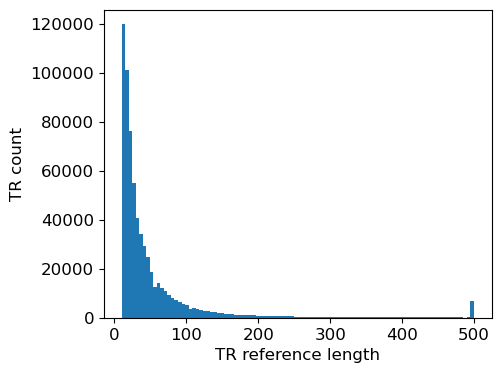

In [83]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(5, 4))
ax.hist([min(ref_len, 500) for ref_len in ref_lens], bins=100)
ax.set_xlabel("TR reference length")
ax.set_ylabel("TR count");

## Get stats for Zev

In [42]:
%%bash

low_map="/pbi/flash/wrowell/workflow_resources/resources/stratifications/mappability/GRCh38_lowmappabilityall.bed.gz"

#zcat output/allele_db.gz | awk -F '_' '{OFS="\t"; print $1, $2, $3}' | uniq | sort -k 1,1 -k 2,2n -k 3,3n > scratch/filtered_regions.bed

bedtools intersect -a scratch/filtered_regions.bed -b $low_map -wa -wb | cut -f 1-3 | sort -k 1,1 -k 2,2n -k 3,3n | wc -l


56078


In [31]:
tr_lens = []
with open("scratch/filtered_regions.bed", "r") as file:
    for line in file:
        chrom, start, end = line.split()
        tr_len = int(end) - int(start)
        tr_lens.append(tr_len)
#            chrom, start, end = sl[0].split("_")[:3]
#            start, end = int(start), int(end)
#            print(f"{chrom}\t{start}\t{end}", file=out_file)

In [44]:
100 * len([tr_len for tr_len in tr_lens if tr_len > 100]) / len(tr_lens)

10.228277910970395

In [37]:
len([tr_len for tr_len in tr_lens if tr_len > 200])

24251

In [ ]:
3601702